### Purpose: This Notebook is used to train binary classification model for Ladung VA

In [1]:
import os
from ast import literal_eval
import pandas as pd
import spacy
import re
from spacy.tokenizer import Tokenizer
import matplotlib.pyplot as plt
import dill

In [2]:
data = pd.read_csv(r"./data/TRAINING_data_with_random_attachments.csv")


In [3]:
data

,text,object_key,document_type,is_ladung,cleaned_text,text_w_tags
0,Katja Schmidt\nKasernenstraße 12 Gebäude F Zi....,16.12.2024/ocr-v2_Dokument_452024_13122024_120...,ladung_va,1,katja schmidt\nkasernenstraße 12 gebäude f zi....,katja schmidt\nkasernenstraße <NUMBER> gebäude...
1,Rafael Gotzein\nBahnhofstr. 44\nGerichtsvollzi...,10.12.2024/ocr-v2_Dokument_196524_09122024_093...,ladung_va,1,rafael gotzein\nbahnhofstr. 44\ngerichtsvollzi...,rafael gotzein\nbahnhofstr. <NUMBER>\ngerichts...
2,Melanie Steffen\nPostfach 16 12\nObergerichtsv...,16.08.2024/ocr-v2_Dokument_148524_15082024_152...,ladung_va,1,melanie steffen\npostfach 16 12\nobergerichtsv...,melanie steffen\npostfach <NUMBER> <NUMBER>\no...
3,Rebekka Hartlmaier\nSchragenhofstraße 27\nHaup...,17.04.2025/ocr-v2_Dokument_53025_16042025_1430...,ladung_va,1,rebekka hartlmaier\nschragenhofstraße 27\nhaup...,rebekka hartlmaier\nschragenhofstraße <NUMBER>...
4,"D. Dormann\nMoritzhöfen 8b, EG\nObergerichtsvo...",01.07.2024/ocr-v2_DR-II_080024_Nachr_Mitlg._an...,ladung_va,1,"d. dormann\nmoritzhöfen 8b, eg\nobergerichtsvo...","d. dormann\nmoritzhöfen 8b, eg\nobergerichtsvo..."
...,...,...,...,...,...,...
5002,Grover\nFriedhelm August Steiner\nBestellnumme...,NaN,mail_attachments,0,grover\nfriedhelm august steiner\nbestellnumme...,grover\nfriedhelm august steiner\nbestellnumme...
5003,Liste des créances\nCréé le: 21.08.2025\nNumér...,NaN,mail_attachments,0,liste des créances\ncréé le: 21.08.2025\nnumér...,liste des créances\ncréé le: <NUMBER>.2025\nnu...
5004,11:06\nRetour Détails de la transaction\nPDF\n...,NaN,mail_attachments,0,"11:06\nretour détails de la transaction\n-209,...",<NUMBER>:<NUMBER>\nretour détails de la transa...
5005,e\nKLINIKUM\nKlinik für Dermatologie\nNÜRNBERG...,NaN,mail_attachments,0,klinikum\nklinik für dermatologie\nnürnberg\nu...,klinikum\nklinik für dermatologie\nnürnberg\nu...


In [4]:
data[data['document_type'] == 'mail_attachments'] # these are randomly added attachments sent to us

,text,object_key,document_type,is_ladung,cleaned_text,text_w_tags
4001,nobilia\nnobilia-Werke J. Stickling GmbH & Co....,NaN,mail_attachments,0,nobilia\nnobilia-werke j. stickling gmbh & co....,nobilia\nnobilia-werke j. stickling gmbh & co....
4002,"Commandée livrée le\nSuivre\nsa, 07.06.2025\na...",NaN,mail_attachments,0,"commandée livrée le\nsuivre\nsa, 07.06.2025\na...","commandée livrée le\nsuivre\nsa, <NUMBER>.2025..."
4003,18:10\n19\nX\nshis\nIBAN\nFR76 3000 4029 9900 ...,NaN,mail_attachments,0,18:10\nshis\niban\nfr76 3000 4029 9900 0105 21...,<NUMBER>:<NUMBER>\nshis\niban\nfr76 <NUMBER> <...
4004,KANZLEI SCHULZE-LOHNE\nKÖLN/BONN\nRA Jens Dene...,NaN,mail_attachments,0,kanzlei schulze-lohne\nköln/bonn\nra jens dene...,kanzlei schulze-lohne\nköln/bonn\nra jens dene...
4005,"Hey Patrick,\ndu hast zum 20.02.2021 erstmalig...",NaN,mail_attachments,0,"hey patrick,\ndu hast zum 20.02.2021 erstmalig...","hey patrick,\ndu hast zum <NUMBER>.2021 erstma..."
...,...,...,...,...,...,...
5002,Grover\nFriedhelm August Steiner\nBestellnumme...,NaN,mail_attachments,0,grover\nfriedhelm august steiner\nbestellnumme...,grover\nfriedhelm august steiner\nbestellnumme...
5003,Liste des créances\nCréé le: 21.08.2025\nNumér...,NaN,mail_attachments,0,liste des créances\ncréé le: 21.08.2025\nnumér...,liste des créances\ncréé le: <NUMBER>.2025\nnu...
5004,11:06\nRetour Détails de la transaction\nPDF\n...,NaN,mail_attachments,0,"11:06\nretour détails de la transaction\n-209,...",<NUMBER>:<NUMBER>\nretour détails de la transa...
5005,e\nKLINIKUM\nKlinik für Dermatologie\nNÜRNBERG...,NaN,mail_attachments,0,klinikum\nklinik für dermatologie\nnürnberg\nu...,klinikum\nklinik für dermatologie\nnürnberg\nu...


In [5]:
data['document_type'].value_counts()

document_type
ladung_va                                 2100
mail_attachments                          1006
monierung_mb                               545
attachment_and_transfer_order              541
approved_seizure                           393
court_inbox                                346
approved_attachment_and_transfer_order      50
enforcement_order                           23
contradiction                                3
Name: count, dtype: int64

In [6]:
data['is_ladung'].value_counts()

is_ladung
0    2907
1    2100
Name: count, dtype: int64

In [7]:
data['document_type'].value_counts()

document_type
ladung_va                                 2100
mail_attachments                          1006
monierung_mb                               545
attachment_and_transfer_order              541
approved_seizure                           393
court_inbox                                346
approved_attachment_and_transfer_order      50
enforcement_order                           23
contradiction                                3
Name: count, dtype: int64

In [8]:
# downlaod spacy for nlp
# pip install spacy
#python -m spacy download de_core_news_md

### Tf-Idf Vectorizer with Custom Spacy Tokenizer

In [9]:
import os

notebook_dir = os.getcwd()
project_dir = os.path.dirname(os.path.dirname(notebook_dir))
print("Notebook Directory:", notebook_dir)
print("Project Directory:", project_dir)
os.chdir(project_dir)

Notebook Directory: /Users/melih.gorgulu/Desktop/Projects/intent_recognition/notebooks/after-court
Project Directory: /Users/melih.gorgulu/Desktop/Projects/intent_recognition


In [10]:
# from spacy.tokenizer import Tokenizer
# from sklearn.feature_extraction.text import TfidfVectorizer
# # Make sure to import ClassificationSpacyLemmaTokenizer from the source code.
# from src.services.models.aftercourt_tokenizer import ClassificationSpacyLemmaTokenizer

# tfidf_vectorizer_experiment = TfidfVectorizer(tokenizer=ClassificationSpacyLemmaTokenizer(),
#                              max_features=200, # Original value: 200
#                              ngram_range=(1,1),
#                              decode_error='ignore',
#                              norm='l2',
#                              min_df=2,
#                              max_df=0.95,
#                              stop_words=None,
#                              lowercase=False)

# # # fit the vectorizer on the text data
# x_transformed_experiment = tfidf_vectorizer_experiment.fit_transform(data['text_w_tags'])
# tfidf_vectorizer_experiment.get_feature_names_out()
# tfidf_vectorizer_experiment.vocabulary_

In [11]:

X_text = data['text_w_tags']
y = data['is_ladung']

# train test split
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set size: {len(X_train_text)}, Test set size: {len(X_test_text)}")
print(f"Train set is ladung dist: {y_train.value_counts(normalize=True)}")
print(f"Test set is ladung dist: {y_test.value_counts(normalize=True)}")


Train set size: 4005, Test set size: 1002
Train set is ladung dist: is_ladung
0    0.580524
1    0.419476
Name: proportion, dtype: float64
Test set is ladung dist: is_ladung
0    0.580838
1    0.419162
Name: proportion, dtype: float64


In [12]:
# CREATE A CLASSIFICATION PIPELINE
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
# Make sure to import ClassificationSpacyLemmaTokenizer from the source code.
from src.services.models.aftercourt_tokenizer import ClassificationSpacyLemmaTokenizer

classification_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(tokenizer=ClassificationSpacyLemmaTokenizer(),
                             max_features=200, # Original value: 200
                             ngram_range=(1,1),
                             norm='l2',
                             min_df=2,
                             max_df=0.95,
                             stop_words=None,
                             lowercase=False)),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))

])

classification_pipeline.fit(X_train_text, y_train)
#joblib.dump(classification_pipeline, 'ladung_clf_pipeline.joblib')
pickle.dump(classification_pipeline, open("classification_pipeline_with_mail_attachments_new.pickle", "wb"))

/Users/melih.gorgulu/miniconda3/envs/intent-recog/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [13]:
dill.dump(classification_pipeline, open("classification_pipeline_with_mail_attachments_new.dill", "wb"))

In [14]:
y_pred = classification_pipeline.predict(X_test_text)

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)


print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

"""
    true negatives is
    :math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, true positives is
    :math:`C_{1,1}` and false positives is :math:`C_{0,1}
"""

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       582
           1       1.00      1.00      1.00       420

    accuracy                           1.00      1002
   macro avg       1.00      1.00      1.00      1002
weighted avg       1.00      1.00      1.00      1002


Confusion Matrix:
[[582   0]
 [  0 420]]


'\n    true negatives is\n    :math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, true positives is\n    :math:`C_{1,1}` and false positives is :math:`C_{0,1}\n'

#### Check token importances

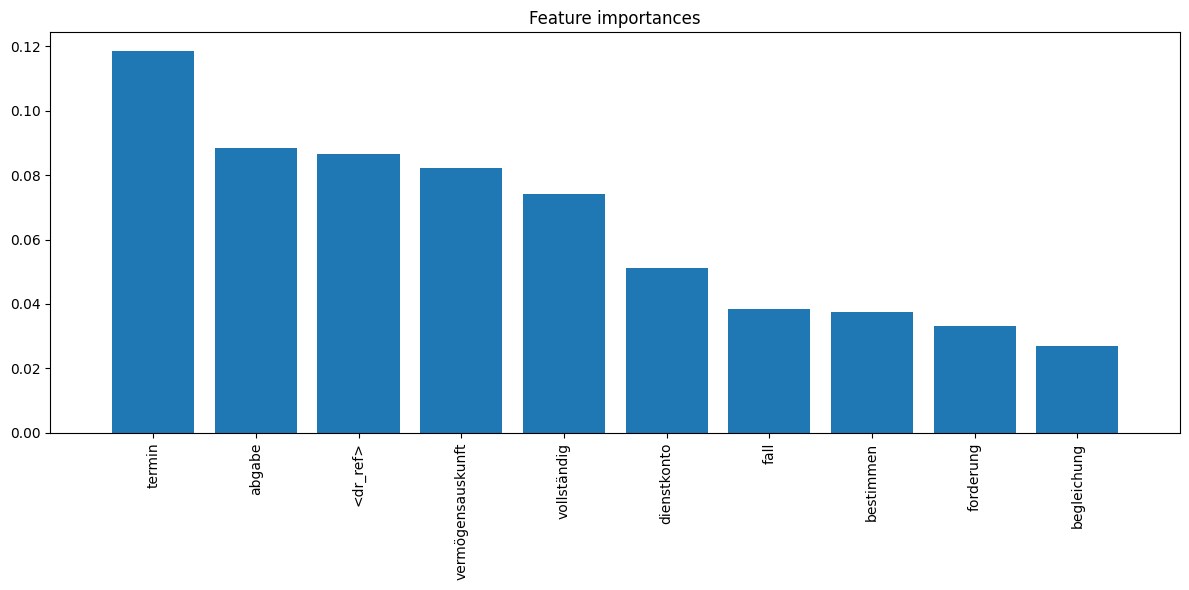

In [16]:
# plot feature importance of the random forest classifier
import numpy as np
feature_names = classification_pipeline.named_steps['tfidf'].get_feature_names_out()
importances = classification_pipeline.named_steps['clf'].feature_importances_
indices = np.argsort(importances)[::-1]
# Plot the feature importances of the forest
plt.figure(figsize=(12, 6))
plt.title("Feature importances")
plt.bar(range(10), importances[indices][:10], align="center")
plt.xticks(range(10), [feature_names[i] for i in indices][:10], rotation=90)
plt.xlim([-1, 10])
plt.tight_layout()
plt.show()